# Model Predictive Control

In the Direct Methods notebook, we solved a finite-horizon optimal-control problem:

$$
\min_{X,U} J(X,U)
$$

subject to:

$$
x_{k+1}=f(x_k,u_k)
$$

and other state or control constraints.

The optimizer produced a complete trajectory:

$$
X^*=
\{x_0^*,\ldots,x_N^*\}
$$

and control sequence:

$$
U^*=
\{u_0^*,\ldots,u_{N-1}^*\}.
$$

If the system starts from the expected initial condition and nothing changes, we could apply this complete control sequence.

However, real systems experience:

- disturbances,
- modeling errors,
- changing environments,
- measurement errors,
- unexpected state deviations.

Model Predictive Control addresses this by repeatedly solving a finite-horizon optimal-control problem using the latest measured state.

The main idea is:

$$
\boxed{
\text{predict}
\rightarrow
\text{optimize}
\rightarrow
\text{apply first control}
\rightarrow
\text{measure again}
\rightarrow
\text{repeat}
}
$$

## 1. Receding-Horizon Control

At the current time $t$, suppose the measured state is:

$$
x_t.
$$

MPC solves a finite-horizon optimization problem over the next $N$ steps:

$$
\boxed{
\min_{u_{0|t},\ldots,u_{N-1|t}}
J_t
}
$$

subject to predicted dynamics:

$$
x_{k+1|t}=
f(x_{k|t},u_{k|t})
$$

with:

$$
x_{0|t}=x_t.
$$

The notation:

$$
x_{k|t}
$$

means:

> the state predicted $k$ steps into the future using information available at current time $t$.

The optimizer produces:

$$
U_t^*=
\{
u_{0|t}^*,
u_{1|t}^*,
\ldots,
u_{N-1|t}^*
\}.
$$

Only the first control is applied:

$$
\boxed{
u_t=u_{0|t}^*.
}
$$

The system then evolves to a new measured state:

$$
x_{t+1}.
$$

The horizon is shifted forward and the optimization is solved again.

## 2. Why Re-Optimize?

Suppose the previous MPC solution predicted:

$$
x_{1|t}^*.
$$

After applying:

$$
u_{0|t}^*,
$$

the actual system may instead reach:

$$
x_{t+1}
\neq
x_{1|t}^*.
$$

This difference may result from:

- disturbances,
- model mismatch,
- new measurements,
- environmental changes.

Rather than continuing with the old planned controls, MPC solves a new optimization problem using:

$$
x_{0|t+1}=x_{t+1}.
$$

Therefore:

$$
\boxed{
\text{repeated open-loop optimization}
\rightarrow
\text{closed-loop behavior}.
}
$$

## 3. First MPC Problem

Consider the discrete system:

$$
x_{k+1}=x_k+u_k.
$$

The objective is to move toward:

$$
x_{\text{goal}}=5.
$$

At every MPC step, solve:

$$
\min_U
\left[
\sum_{k=0}^{N-1}
\left(
q(x_{k|t}-x_{\text{goal}})^2
+
r u_{k|t}^2
\right)
+
q_f(x_{N|t}-x_{\text{goal}})^2
\right]
$$

subject to:

$$
x_{k+1|t}=
x_{k|t}+u_{k|t}
$$

and:

$$
-1\leq u_{k|t}\leq1.
$$

Only:

$$
u_{0|t}^*
$$

is applied before the optimization is solved again.

In [39]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# Problem parameters
x_goal = 5.0

q = 1.0
r = 0.1
q_f = 10.0

N = 5               # prediction horizon
u_min = -1.0
u_max = 1.0

## 4. MPC Optimization Problem

At each control step, the current measured state is:

$$
x_t.
$$

The optimization variables are only the future controls:

$$
U=
\begin{bmatrix}
u_{0|t},
u_{1|t},
\ldots,
u_{N-1|t}
\end{bmatrix}.
$$

The predicted states are generated recursively using:

$$
x_{k+1|t}=
x_{k|t}+u_{k|t}.
$$

The cost is:

$$
J=
\sum_{k=0}^{N-1}
\left[
q(x_{k|t}-x_{\text{goal}})^2
+
ru_{k|t}^2
\right]
+
q_f(x_{N|t}-x_{\text{goal}})^2.
$$

In [40]:
def predict_trajectory(x0, U):
    X = np.zeros(len(U) + 1)
    X[0] = x0

    for k in range(len(U)):
        X[k + 1] = X[k] + U[k]

    return X

In [41]:
def mpc_cost(U, x_current):
    X = predict_trajectory(x_current, U)

    cost = 0.0

    for k in range(N):
        state_error = X[k] - x_goal

        cost += (
            q * state_error**2
            + r * U[k]**2
        )

    terminal_error = X[-1] - x_goal

    cost += q_f * terminal_error**2

    return cost

In [42]:
def solve_mpc(x_current, U_guess=None):

    if U_guess is None:
        U_guess = np.zeros(N)

    bounds = [
        (u_min, u_max)
        for _ in range(N)
    ]

    result = minimize(
        mpc_cost,
        U_guess,
        args=(x_current,),
        method="SLSQP",
        bounds=bounds
    )

    U_opt = result.x

    X_pred = predict_trajectory(
        x_current,
        U_opt
    )

    return X_pred, U_opt

## 5. Receding-Horizon Loop

At each real system timestep:

1. measure the current state,
2. solve the finite-horizon optimization,
3. obtain the predicted trajectory,
4. execute only the first optimal control,
5. measure the new state,
6. solve again.

Thus:

$$
\boxed{
U_t^*=
[u_{0|t}^*,\ldots,u_{N-1|t}^*]
}
$$

is calculated, but only:

$$
\boxed{
u_t=u_{0|t}^*
}
$$

is executed.

In [43]:
simulation_steps = 10

x = 0.0

X_actual = [x]
U_applied = []

predictions = []

U_guess = np.zeros(N)

for t in range(simulation_steps):

    # Solve MPC using current measured state
    X_pred, U_opt = solve_mpc(
        x,
        U_guess
    )

    predictions.append(
        X_pred.copy()
    )

    # Apply only the first control
    u = U_opt[0]

    # Actual system evolution
    x = x + u

    X_actual.append(x)
    U_applied.append(u)

    # Warm start:
    # shift previous solution forward
    U_guess[:-1] = U_opt[1:]
    U_guess[-1] = U_opt[-1]

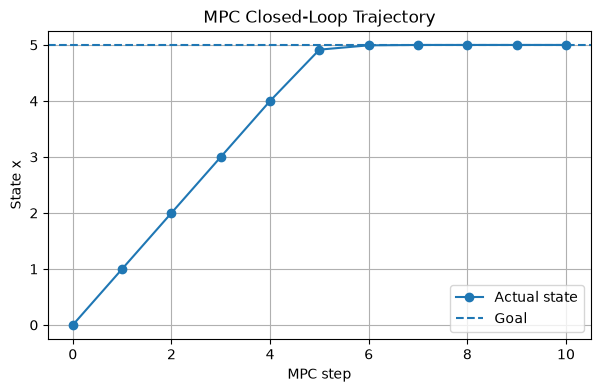

In [44]:
plt.figure(figsize=(7, 4))

plt.plot(
    range(len(X_actual)),
    X_actual,
    marker="o",
    label="Actual state"
)

plt.axhline(
    x_goal,
    linestyle="--",
    label="Goal"
)

plt.xlabel("MPC step")
plt.ylabel("State x")
plt.title("MPC Closed-Loop Trajectory")
plt.legend()
plt.grid(True)
plt.show()

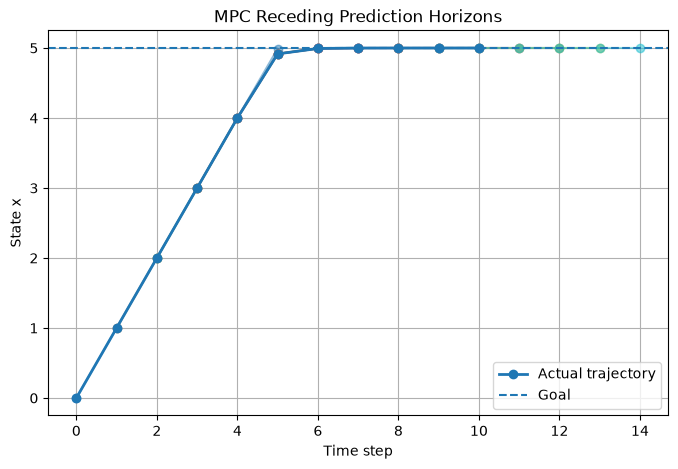

In [45]:
plt.figure(figsize=(8, 5))

for t, X_pred in enumerate(predictions):

    prediction_times = np.arange(
        t,
        t + N + 1
    )

    plt.plot(
        prediction_times,
        X_pred,
        marker="o",
        alpha=0.5
    )

plt.plot(
    range(len(X_actual)),
    X_actual,
    marker="o",
    linewidth=2,
    label="Actual trajectory"
)

plt.axhline(
    x_goal,
    linestyle="--",
    label="Goal"
)

plt.xlabel("Time step")
plt.ylabel("State x")
plt.title("MPC Receding Prediction Horizons")
plt.legend()
plt.grid(True)
plt.show()

## 6. Observation

Each MPC optimization predicts an entire future trajectory.

However, only the first action is executed.

After the system moves, the horizon is shifted and the optimization is solved again.

Therefore:

$$
\boxed{
\text{predicted trajectory}
\neq
\text{committed trajectory}.
}
$$

The future plan is continuously updated using new state information.

This is the defining behavior of receding-horizon control.

## 7. MPC Under a Disturbance

So far, the prediction model and the actual system behaved identically:

$$
x_{k+1}=x_k+u_k.
$$

Now suppose the real system experiences an unexpected disturbance.

The MPC prediction model remains:

$$
x_{k+1|t}=x_{k|t}+u_{k|t},
$$

but the actual system evolves as:

$$
x_{t+1}=
x_t+u_t+w_t,
$$

where:

$$
w_t
$$

is an external disturbance.

MPC does not know the disturbance in advance.

However, after the disturbed state is measured, the next optimization starts from the new actual state.

Thus MPC can compensate through repeated replanning.

In [46]:
simulation_steps = 10

x = 0.0

X_actual_disturbed = [x]
U_applied_disturbed = []

predictions_disturbed = []

U_guess = np.zeros(N)

for t in range(simulation_steps):

    # Solve MPC from current measured state
    X_pred, U_opt = solve_mpc(
        x,
        U_guess
    )

    predictions_disturbed.append(
        X_pred.copy()
    )

    # Apply only the first control
    u = U_opt[0]

    # Unexpected disturbance
    disturbance = 0.0

    if t == 2:
        disturbance = -1.0

    # Actual system
    x = x + u + disturbance

    X_actual_disturbed.append(x)
    U_applied_disturbed.append(u)

    # Warm start
    U_guess[:-1] = U_opt[1:]
    U_guess[-1] = U_opt[-1]

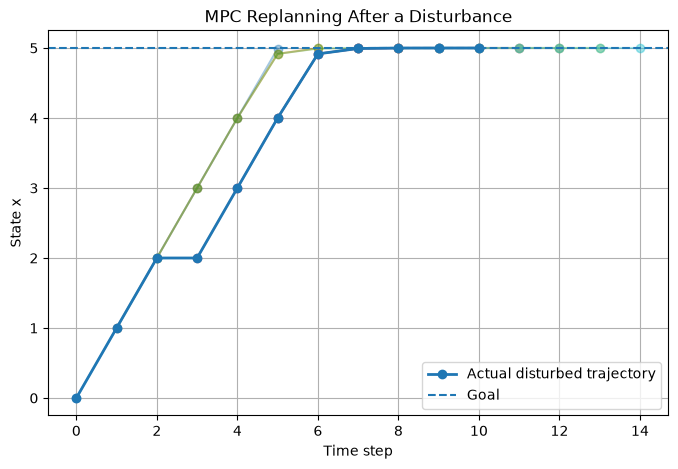

In [47]:
plt.figure(figsize=(8, 5))

for t, X_pred in enumerate(predictions_disturbed):

    prediction_times = np.arange(
        t,
        t + N + 1
    )

    plt.plot(
        prediction_times,
        X_pred,
        marker="o",
        alpha=0.4
    )

plt.plot(
    range(len(X_actual_disturbed)),
    X_actual_disturbed,
    marker="o",
    linewidth=2,
    label="Actual disturbed trajectory"
)

plt.axhline(
    x_goal,
    linestyle="--",
    label="Goal"
)

plt.xlabel("Time step")
plt.ylabel("State x")
plt.title("MPC Replanning After a Disturbance")
plt.legend()
plt.grid(True)
plt.show()

### Observation

The disturbance causes the actual system to deviate from the previously predicted trajectory.

However, MPC does not continue blindly with the old control sequence.

At the next control step, the new measured state becomes:

$$
x_{0|t+1}=x_{t+1}.
$$

A new finite-horizon optimization is solved from this updated state.

Therefore:

$$
\boxed{
\text{disturbance}
\rightarrow
\text{state deviation}
\rightarrow
\text{new measurement}
\rightarrow
\text{new optimization}
}
$$

This repeated correction produces closed-loop behavior.

## Case Study 1 - Nonlinear MPC for a 2D Car

We now apply MPC to the nonlinear kinematic bicycle model.

The requirement is:

> Drive the vehicle from its current state toward a desired target state while respecting actuator limits.

The state is:

$$
x=
\begin{bmatrix}
p_x\\
p_y\\
\theta\\
v
\end{bmatrix}
$$

and the control is:

$$
u=
\begin{bmatrix}
a\\
\delta
\end{bmatrix}.
$$

The continuous-time dynamics are:

$$
\dot p_x=v\cos\theta
$$

$$
\dot p_y=v\sin\theta
$$

$$
\dot\theta=\frac{v}{L}\tan\delta
$$

$$
\dot v=a.
$$

Using Forward Euler:

$$
\boxed{
x_{k+1}=f(x_k,u_k)
}
$$

with:

$$
p_{x,k+1}=
p_{x,k}
+
\Delta t\,v_k\cos\theta_k
$$

$$
p_{y,k+1}=
p_{y,k}
+
\Delta t\,v_k\sin\theta_k
$$

$$
\theta_{k+1}=
\theta_k
+
\Delta t\frac{v_k}{L}\tan\delta_k
$$

$$
v_{k+1}=
v_k+\Delta t\,a_k.
$$

### Prediction Model

At every MPC step, the measured state becomes the initial condition:

$$
\boxed{
x_{0|t}=x_t.
}
$$

For a candidate control sequence:

$$
U_t=
\{
u_{0|t},\ldots,u_{N-1|t}
\},
$$

the predicted trajectory is generated recursively:

$$
x_{k+1|t}=
f(x_{k|t},u_{k|t}).
$$

Thus:

$$
\boxed{
x_t + U_t
\rightarrow
X_t^{pred}.
}
$$

The prediction is used only for optimization.

After applying the first control to the real system, a new state is measured and a new prediction is generated.

### MPC Objective

Let the desired state be:

$$
x_{\text{goal}}=
\begin{bmatrix}
p_x^{goal}\\
p_y^{goal}\\
\theta^{goal}\\
v^{goal}
\end{bmatrix}.
$$

Define the prediction error:

$$
e_{k|t}=
x_{k|t}-x_{\text{goal}}.
$$

The finite-horizon objective is:

$$
\boxed{J_t=
\sum_{k=0}^{N-1}
\left[
e_{k|t}^TQe_{k|t}
+
u_{k|t}^TRu_{k|t}
\right]
+
e_{N|t}^TQ_fe_{N|t}.
}
$$

The matrices:

$$
Q,\quad R,\quad Q_f
$$

determine the trade-off between:

- state tracking,
- control effort,
- terminal accuracy.

### Hard Constraints

The vehicle actuators have physical limits.

Acceleration:

$$
\boxed{
a_{\min}
\le
a_{k|t}
\le
a_{\max}
}
$$

Steering:

$$
\boxed{
\delta_{\min}
\le
\delta_{k|t}
\le
\delta_{\max}
}
$$

The vehicle state can also be constrained.

For example:

$$
\boxed{
v_{\min}
\le
v_{k|t}
\le
v_{\max}.
}
$$

These are hard constraints: the optimizer is only allowed to consider trajectories that satisfy them.

In [70]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# Vehicle parameters
L = 2.5
dt = 0.1

# Prediction horizon
N = 35

# Target state
x_goal = np.array([
    10.0,              # px
    4.0,               # py
    np.deg2rad(20.0),  # heading
    2.0                # velocity
])

# Initial state
x0 = np.array([
    0.0,
    0.0,
    0.0,
    2.0
])

# Cost weights
Q = np.diag([
    2.0,   # px
    4.0,   # py
    2.0,   # heading
    1.0    # velocity
])

R = np.diag([
    0.1,   # acceleration
    0.5    # steering
])

Qf = np.diag([
    10.0,
    20.0,
    10.0,
    5.0
])

# Control limits
a_min = -3.0
a_max = 2.0

delta_min = -0.5
delta_max = 0.5

In [71]:
def vehicle_step(x, u):
    px, py, theta, v = x
    a, delta = u

    return np.array([
        px + dt * v * np.cos(theta),
        py + dt * v * np.sin(theta),
        theta + dt * (v / L) * np.tan(delta),
        v + dt * a
    ])

In [72]:
def predict_vehicle_trajectory(x_current, U_flat):

    U = U_flat.reshape(N, 2)

    X = np.zeros((N + 1, 4))
    X[0] = x_current

    for k in range(N):
        X[k + 1] = vehicle_step(
            X[k],
            U[k]
        )

    return X

### Finite-Horizon Nonlinear Optimization

For the current measured state:

$$
x_t,
$$

the optimization variables are the future controls:

$$
U_t=
\{
u_{0|t},
u_{1|t},
\ldots,
u_{N-1|t}
\}.
$$

The predicted states are generated using the nonlinear vehicle model:

$$
x_{k+1|t}=
f(x_{k|t},u_{k|t}).
$$

The objective is:

$$
J_t=
\sum_{k=0}^{N-1}
\left[
e_{k|t}^TQe_{k|t}
+
u_{k|t}^TRu_{k|t}
\right]
+
e_{N|t}^TQ_fe_{N|t},
$$

where:

$$
e_{k|t}=
x_{k|t}-x_{\text{goal}}.
$$

In [73]:
def vehicle_mpc_cost(U_flat, x_current):

    U = U_flat.reshape(N, 2)

    X = predict_vehicle_trajectory(
        x_current,
        U_flat
    )

    cost = 0.0

    for k in range(N):

        e = X[k] - x_goal

        cost += (
            e.T @ Q @ e
            + U[k].T @ R @ U[k]
        )

    e_terminal = X[-1] - x_goal

    cost += (
        e_terminal.T
        @ Qf
        @ e_terminal
    )

    return cost

In [74]:
control_bounds = []

for k in range(N):

    control_bounds.append(
        (a_min, a_max)
    )

    control_bounds.append(
        (delta_min, delta_max)
    )

In [75]:
def solve_vehicle_mpc(
    x_current,
    U_guess=None
):

    if U_guess is None:
        U_guess = np.zeros((N, 2))

    result = minimize(
        vehicle_mpc_cost,
        U_guess.flatten(),
        args=(x_current,),
        method="SLSQP",
        bounds=control_bounds,
        options={
            "maxiter": 200,
            "ftol": 1e-6
        }
    )

    U_opt = result.x.reshape(N, 2)

    X_pred = predict_vehicle_trajectory(
        x_current,
        result.x
    )

    return X_pred, U_opt, result

In [76]:
U_guess = np.zeros((N, 2))

X_pred, U_opt, result = solve_vehicle_mpc(
    x0,
    U_guess
)

print("Optimization success:", result.success)
print("Final cost:", result.fun)

print("\nPredicted terminal state:")
print(X_pred[-1])

print("\nDesired state:")
print(x_goal)

Optimization success: True
Final cost: 3223.7763686585035

Predicted terminal state:
[10.49027616  4.14813942  0.26098375  1.84431409]

Desired state:
[10.          4.          0.34906585  2.        ]


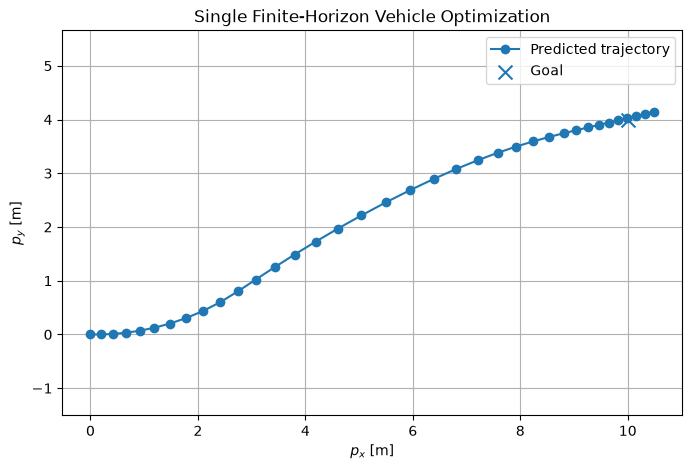

In [77]:
plt.figure(figsize=(8, 5))

plt.plot(
    X_pred[:, 0],
    X_pred[:, 1],
    marker="o",
    label="Predicted trajectory"
)

plt.scatter(
    x_goal[0],
    x_goal[1],
    marker="x",
    s=100,
    label="Goal"
)

plt.xlabel("$p_x$ [m]")
plt.ylabel("$p_y$ [m]")
plt.title("Single Finite-Horizon Vehicle Optimization")
plt.axis("equal")
plt.grid(True)
plt.legend()
plt.show()

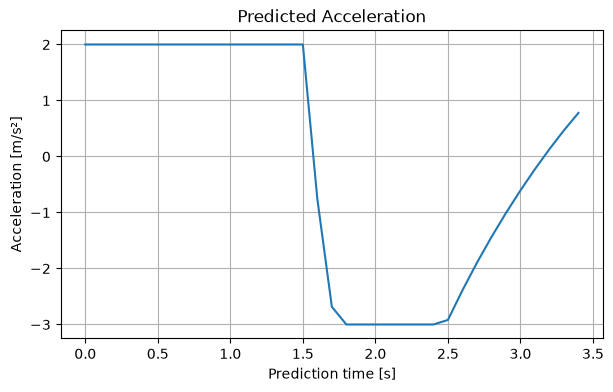

In [78]:
prediction_time = np.arange(N) * dt

plt.figure(figsize=(7, 4))

plt.plot(
    prediction_time,
    U_opt[:, 0]
)

plt.xlabel("Prediction time [s]")
plt.ylabel("Acceleration [m/s²]")
plt.title("Predicted Acceleration")
plt.grid(True)
plt.show()

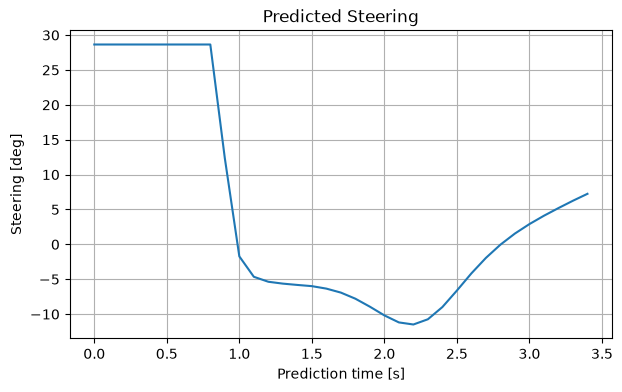

In [79]:
plt.figure(figsize=(7, 4))

plt.plot(
    prediction_time,
    np.rad2deg(U_opt[:, 1])
)

plt.xlabel("Prediction time [s]")
plt.ylabel("Steering [deg]")
plt.title("Predicted Steering")
plt.grid(True)
plt.show()

#### Observation

The finite-horizon optimizer predicts a complete future state and control trajectory.

However, in MPC we do not execute the complete sequence.

Only the first optimized control:

$$
u_{0|t}^*
$$

is applied.

The remaining controls are predictions and may be replaced completely at the next MPC step.

### Nonlinear MPC Loop

At each real control step:

1. measure the current vehicle state,
2. solve the nonlinear finite-horizon problem,
3. obtain the predicted state and control trajectories,
4. apply only the first control,
5. propagate the real vehicle,
6. shift the previous control sequence for warm start,
7. solve again.

Thus:

$$
\boxed{
\text{measure}
\rightarrow
\text{predict}
\rightarrow
\text{optimize}
\rightarrow
\text{apply}
\rightarrow
\text{repeat}.
}
$$

In [80]:
simulation_steps = 60

x = x0.copy()

X_actual = [x.copy()]
U_applied = []

prediction_history = []

U_guess = np.zeros((N, 2))

for t in range(simulation_steps):

    X_pred, U_opt, result = solve_vehicle_mpc(
        x,
        U_guess
    )

    if not result.success:
        print(
            f"MPC optimization failed at step {t}"
        )
        break

    prediction_history.append(
        X_pred.copy()
    )

    # Apply only first control
    u = U_opt[0]

    # Real vehicle propagation
    x = vehicle_step(x, u)

    X_actual.append(x.copy())
    U_applied.append(u.copy())

    # Warm start
    U_guess[:-1] = U_opt[1:]
    U_guess[-1] = U_opt[-1]

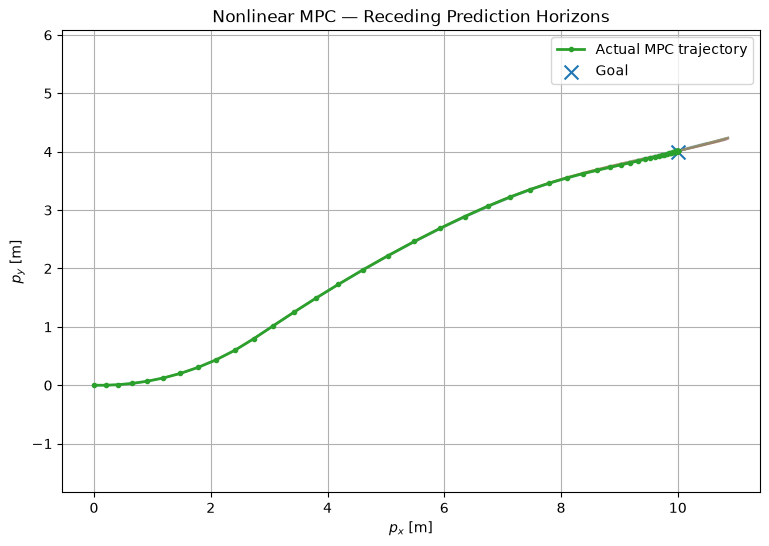

In [81]:
X_actual = np.array(X_actual)
U_applied = np.array(U_applied)

plt.figure(figsize=(9, 6))

# Show some predicted horizons
for t in range(
    0,
    len(prediction_history),
    5
):
    Xp = prediction_history[t]

    plt.plot(
        Xp[:, 0],
        Xp[:, 1],
        alpha=0.35
    )

# Actual closed-loop trajectory
plt.plot(
    X_actual[:, 0],
    X_actual[:, 1],
    marker="o",
    markersize=3,
    linewidth=2,
    label="Actual MPC trajectory"
)

plt.scatter(
    x_goal[0],
    x_goal[1],
    marker="x",
    s=100,
    label="Goal"
)

plt.xlabel("$p_x$ [m]")
plt.ylabel("$p_y$ [m]")
plt.title("Nonlinear MPC — Receding Prediction Horizons")
plt.axis("equal")
plt.grid(True)
plt.legend()
plt.show()

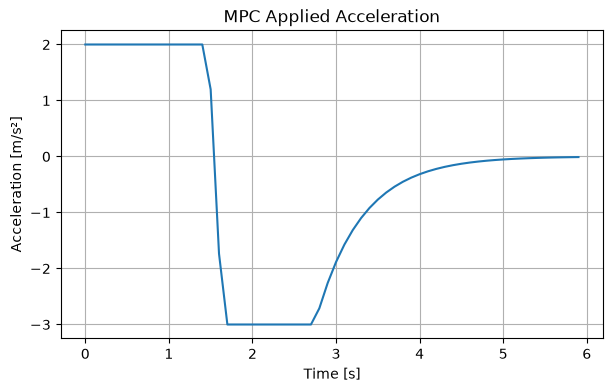

In [82]:
time_actual = np.arange(
    len(U_applied)
) * dt

plt.figure(figsize=(7, 4))

plt.plot(
    time_actual,
    U_applied[:, 0]
)

plt.xlabel("Time [s]")
plt.ylabel("Acceleration [m/s²]")
plt.title("MPC Applied Acceleration")
plt.grid(True)
plt.show()

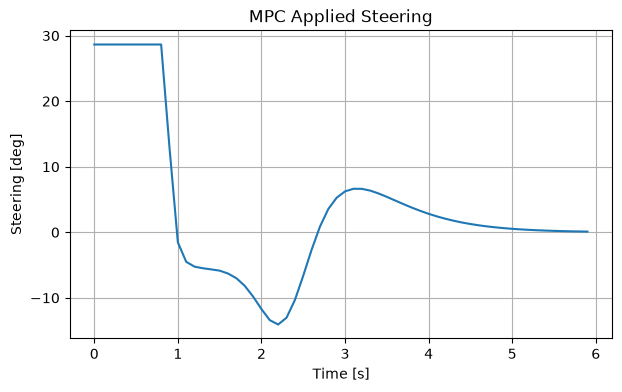

In [83]:
plt.figure(figsize=(7, 4))

plt.plot(
    time_actual,
    np.rad2deg(U_applied[:, 1])
)

plt.xlabel("Time [s]")
plt.ylabel("Steering [deg]")
plt.title("MPC Applied Steering")
plt.grid(True)
plt.show()

### Nonlinear MPC Takeaway

The optimization problem itself is a finite-horizon nonlinear trajectory optimization problem.

MPC is created by repeatedly solving this problem and applying only the first action.

Therefore:

$$
\boxed{
\text{finite-horizon trajectory optimization}+
\text{receding-horizon execution}
=\text{MPC}.
}
$$

The nonlinear vehicle model is used to predict future states, while actuator bounds restrict the set of feasible controls.

At every step, the future prediction is updated using the latest measured state.

## Case Study 2: Obstacle Avoidance as a State Constraint

Suppose a circular obstacle is centered at:

$$
p_{\text{obs}}=
\begin{bmatrix}
p_x^{obs}\\
p_y^{obs}
\end{bmatrix}
$$

with obstacle radius:

$$
r_{\text{obs}}.
$$

We also introduce a safety margin:

$$
r_{\text{margin}}.
$$

The total required clearance is:

$$
\boxed{
r_{\text{safe}}=
r_{\text{obs}}
+
r_{\text{margin}}.
}
$$

For every predicted vehicle position:

$$
p_{k|t}=
\begin{bmatrix}
p_{x,k|t}\\
p_{y,k|t}
\end{bmatrix},
$$

we require:

$$
\boxed{
\|p_{k|t}-p_{\text{obs}}\|^2
\geq
r_{\text{safe}}^2.
}
$$

This is a hard state constraint.

The optimizer is therefore not allowed to predict a trajectory that enters the safety region around the obstacle.

In [84]:
# Obstacle
obstacle = np.array([
    5.0,   # px
    2.0    # py
])

r_obs = 0.8
r_margin = 0.5

r_safe = r_obs + r_margin

In [85]:
def obstacle_constraint(U_flat, x_current):

    X = predict_vehicle_trajectory(
        x_current,
        U_flat
    )

    constraints = []

    for k in range(1, N + 1):

        px = X[k, 0]
        py = X[k, 1]

        dx = px - obstacle[0]
        dy = py - obstacle[1]

        distance_squared = dx**2 + dy**2

        constraints.append(
            distance_squared - r_safe**2
        )

    return np.array(constraints)

### Constraint Interpretation

For every predicted state define:

$$
g_k=
(p_{x,k}-p_x^{obs})^2+
(p_{y,k}-p_y^{obs})^2-
r_{\text{safe}}^2.
$$

The MPC constraint is:

$$
\boxed{
g_k\geq0.
}
$$

Therefore:

$$
g_k>0
\rightarrow
\text{safe}
$$

$$
g_k=0
\rightarrow
\text{safety boundary}
$$

$$
g_k<0
\rightarrow
\text{constraint violation}.
$$

In [86]:
def solve_vehicle_mpc_obstacle(
    x_current,
    U_guess=None
):

    if U_guess is None:
        U_guess = np.zeros((N, 2))

    constraints = {
        "type": "ineq",
        "fun": obstacle_constraint,
        "args": (x_current,)
    }

    result = minimize(
        vehicle_mpc_cost,
        U_guess.flatten(),
        args=(x_current,),
        method="SLSQP",
        bounds=control_bounds,
        constraints=constraints,
        options={
            "maxiter": 300,
            "ftol": 1e-6
        }
    )

    U_opt = result.x.reshape(N, 2)

    X_pred = predict_vehicle_trajectory(
        x_current,
        result.x
    )

    return X_pred, U_opt, result

In [87]:
U_guess = np.zeros((N, 2))

X_pred_obs, U_opt_obs, result_obs = (
    solve_vehicle_mpc_obstacle(
        x0,
        U_guess
    )
)

print("Optimization success:", result_obs.success)
print("Message:", result_obs.message)

print(
    "Minimum obstacle constraint:",
    np.min(
        obstacle_constraint(
            U_opt_obs.flatten(),
            x0
        )
    )
)

Optimization success: True
Message: Optimization terminated successfully
Minimum obstacle constraint: 6.586661949192774e-08


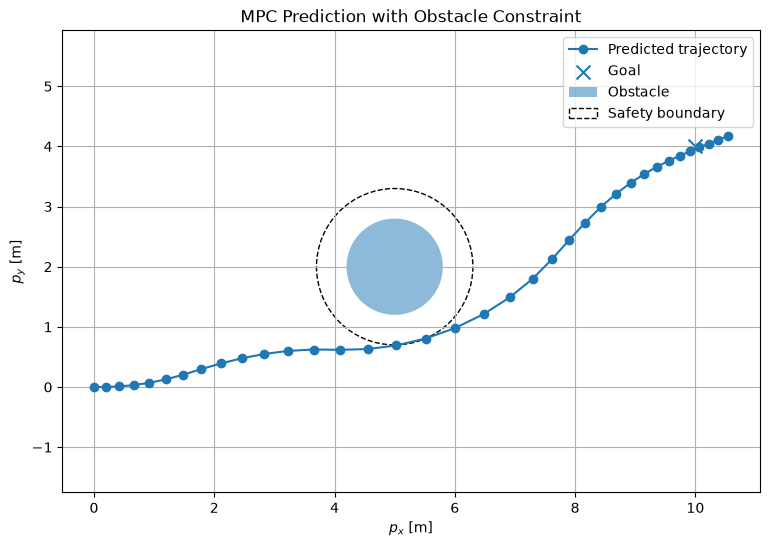

In [88]:
plt.figure(figsize=(9, 6))

plt.plot(
    X_pred_obs[:, 0],
    X_pred_obs[:, 1],
    marker="o",
    label="Predicted trajectory"
)

plt.scatter(
    x_goal[0],
    x_goal[1],
    marker="x",
    s=100,
    label="Goal"
)

# Physical obstacle
obstacle_circle = plt.Circle(
    obstacle,
    r_obs,
    alpha=0.5,
    label="Obstacle"
)

# Safety boundary
safety_circle = plt.Circle(
    obstacle,
    r_safe,
    fill=False,
    linestyle="--",
    label="Safety boundary"
)

ax = plt.gca()
ax.add_patch(obstacle_circle)
ax.add_patch(safety_circle)

plt.xlabel("$p_x$ [m]")
plt.ylabel("$p_y$ [m]")
plt.title("MPC Prediction with Obstacle Constraint")
plt.axis("equal")
plt.grid(True)
plt.legend()
plt.show()

In [90]:
simulation_steps = 70

x = x0.copy()

X_actual_obs = [x.copy()]
U_applied_obs = []

prediction_history_obs = []

U_guess = np.zeros((N, 2))

for t in range(simulation_steps):

    X_pred, U_opt, result = (
        solve_vehicle_mpc_obstacle(
            x,
            U_guess
        )
    )

    if not result.success:
        print(
            f"MPC optimization failed at step {t}"
        )
        break

    prediction_history_obs.append(
        X_pred.copy()
    )

    # Execute only first control
    u = U_opt[0]

    x = vehicle_step(x, u)

    X_actual_obs.append(x.copy())
    U_applied_obs.append(u.copy())

    # Warm start
    U_guess[:-1] = U_opt[1:]
    U_guess[-1] = U_opt[-1]

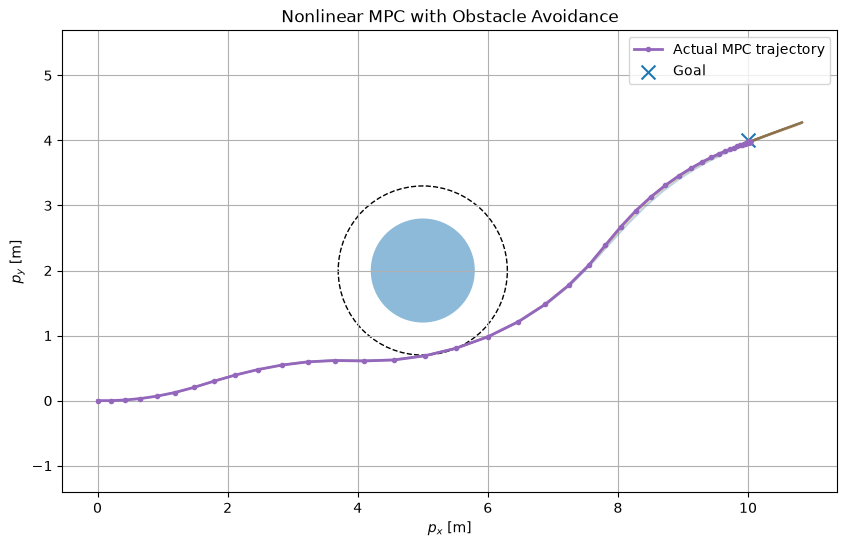

In [91]:
X_actual_obs = np.array(X_actual_obs)
U_applied_obs = np.array(U_applied_obs)

plt.figure(figsize=(10, 6))

for t in range(
    0,
    len(prediction_history_obs),
    5
):
    Xp = prediction_history_obs[t]

    plt.plot(
        Xp[:, 0],
        Xp[:, 1],
        alpha=0.3
    )

plt.plot(
    X_actual_obs[:, 0],
    X_actual_obs[:, 1],
    linewidth=2,
    marker="o",
    markersize=3,
    label="Actual MPC trajectory"
)

plt.scatter(
    x_goal[0],
    x_goal[1],
    marker="x",
    s=100,
    label="Goal"
)

obstacle_circle = plt.Circle(
    obstacle,
    r_obs,
    alpha=0.5
)

safety_circle = plt.Circle(
    obstacle,
    r_safe,
    fill=False,
    linestyle="--"
)

ax = plt.gca()
ax.add_patch(obstacle_circle)
ax.add_patch(safety_circle)

plt.xlabel("$p_x$ [m]")
plt.ylabel("$p_y$ [m]")
plt.title("Nonlinear MPC with Obstacle Avoidance")
plt.axis("equal")
plt.grid(True)
plt.legend()
plt.show()

### Constrained MPC Observation

The obstacle is represented as a hard state constraint:

$$
\|p_{k|t}-p_{\text{obs}}\|
\geq
r_{\text{safe}}.
$$

At every MPC step, the optimizer predicts a new trajectory that must satisfy this constraint over the prediction horizon.

As the vehicle moves, the prediction horizon shifts and the obstacle is reconsidered from the latest state.

Thus:

$$
\boxed{
\text{current state}
+
\text{vehicle dynamics}
+
\text{objective}
+
\text{constraints}
\rightarrow
\text{new feasible prediction}.
}
$$

### Horizon-Length Observation

With a short prediction horizon, the obstacle may enter the MPC horizon too late for the vehicle to find a feasible avoidance maneuver.

Increasing the horizon gives the optimizer more time to anticipate the obstacle and begin steering earlier.

Thus:

$$
\boxed{
\text{short horizon}
\rightarrow
\text{less anticipation}
}
$$

while:

$$
\boxed{
\text{long horizon}
\rightarrow
\text{more anticipation but more computation}.
}
$$

This experiment also shows that feasibility depends not only on the constraints themselves, but also on:

- prediction horizon,
- system dynamics,
- actuator limits,
- current state,
- numerical initialization.

## 8. Persistent Feasibility

At the current time $t$, suppose the MPC optimization has a feasible solution:

$$
U_t^* =
\{
u_{0|t}^*,
\ldots,
u_{N-1|t}^*
\}.
$$

This means the predicted trajectory satisfies all constraints over the current horizon.

However, after applying:

$$
u_{0|t}^*,
$$

the system moves to:

$$
x_{t+1}.
$$

A new optimization problem must then be solved.

Feasibility at time $t$ does not automatically guarantee feasibility at time $t+1$.

Persistent feasibility means:

$$
\boxed{
\text{feasible now}
\Rightarrow
\text{feasible at all future MPC steps}.
}
$$

### Why Current Feasibility Is Not Enough

A finite-horizon MPC solution guarantees constraint satisfaction only over the current prediction horizon.

It is possible that:

$$
x_{N|t}
$$

is feasible at the end of the current horizon, but there is no admissible control that can keep the system feasible afterward.

Therefore:

$$
\boxed{
\text{finite-horizon feasibility}
\neq
\text{future feasibility guarantee}.
}
$$

To address this, MPC can impose additional structure on the terminal state.

## 9. Control-Invariant Terminal Set

A set:

$$
\mathcal{X}_f
$$

is called control invariant if:

$$
\boxed{
x\in\mathcal{X}_f
\Rightarrow
\exists u\in\mathcal U
\text{ such that }
f(x,u)\in\mathcal{X}_f.
}
$$

In other words:

> Once the system reaches $\mathcal{X}_f$, there is always at least one admissible control that keeps the system inside the set.

MPC can impose the terminal constraint:

$$
\boxed{
x_{N|t}\in\mathcal{X}_f.
}
$$

### Role of the Terminal Set

Without a terminal constraint:

$$
x_{N|t}
$$

may lie anywhere in the feasible state space.

With:

$$
x_{N|t}\in\mathcal{X}_f,
$$

the optimizer must finish the prediction in a region from which future feasibility can be maintained.

Thus:

$$
\boxed{
\text{terminal invariant set}
\rightarrow
\text{safe continuation beyond the horizon}.
}
$$

## 10. Shifted Feasible Sequence

Suppose the optimal MPC sequence at time $t$ is:

$$
U_t^*=
\{
u_{0|t}^*,
u_{1|t}^*,
\ldots,
u_{N-1|t}^*
\}
$$

with:

$$
x_{N|t}^*\in\mathcal{X}_f.
$$

After applying:

$$
u_{0|t}^*,
$$

consider the candidate sequence at time $t+1$:

$$
\{
u_{1|t}^*,
u_{2|t}^*,
\ldots,
u_{N-1|t}^*,
u_f
\}.
$$

Since $\mathcal{X}_f$ is control invariant, there exists an admissible $u_f$ such that the new terminal state remains inside:

$$
\mathcal{X}_f.
$$

Therefore, a feasible candidate solution exists at the next MPC step.

This gives the intuition behind:

$$
\boxed{
\text{control-invariant terminal set}
\rightarrow
\text{persistent feasibility}.
}
$$

### Our Current MPC Implementation

Our obstacle-avoidance MPC uses:

$$
x_{k+1}=f(x_k,u_k),
$$

input constraints, and obstacle constraints.

However, we have not imposed:

$$
x_{N|t}\in\mathcal{X}_f.
$$

Therefore, our controller does not have a formal persistent-feasibility guarantee.

Increasing the prediction horizon improved the practical behavior:

$$
N=20
\rightarrow
\text{failure}
$$

$$
N=35
\rightarrow
\text{successful avoidance}.
$$

But:

$$
\boxed{
\text{longer horizon}
\neq
\text{formal persistent-feasibility guarantee}.
}
$$

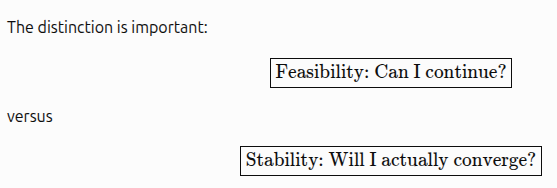

## 11. Stability of MPC

Persistent feasibility answers:

> If the MPC problem is feasible now, can we continue finding feasible solutions in the future?

However, this does not automatically guarantee:

$$
x_t \rightarrow x_{\text{goal}}.
$$

A controller could remain feasible indefinitely without converging to the desired equilibrium.

Therefore, MPC stability asks:

> Does the receding-horizon controller drive the closed-loop system toward the desired equilibrium?

Thus:

$$
\boxed{
\text{persistent feasibility}
\neq
\text{stability}.
}
$$

## 12. Terminal Ingredients

A common stabilizing MPC formulation uses two terminal ingredients:

### Terminal set

$$
x_{N|t}\in\mathcal X_f.
$$

The terminal set is chosen so that the system can be safely controlled once it enters this region.

### Terminal cost

$$
V_f(x_{N|t}).
$$

The MPC objective becomes:

$$
\boxed{
J_t=
\sum_{k=0}^{N-1}
\ell(x_{k|t},u_{k|t})
+
V_f(x_{N|t}).
}
$$

The terminal cost approximates the cost of continuing to control the system beyond the finite prediction horizon.

## 13. Terminal Controller and Decreasing Terminal Cost

Suppose there exists a local controller:

$$
u=\kappa_f(x)
$$

inside the terminal set:

$$
\mathcal X_f.
$$

We choose the terminal cost so that:

$$
\boxed{
V_f(f(x,\kappa_f(x)))-
V_f(x)
\leq
-\ell(x,\kappa_f(x)).
}
$$

This means that under the terminal controller, the terminal value decreases as the system evolves.

Therefore, $V_f$ can act similarly to a Lyapunov function in the terminal region.

## 14. MPC Cost as a Lyapunov Function

Let:

$$
J_t^*
$$

denote the optimal MPC cost at time $t$.

Using the shifted feasible sequence and the terminal controller, we can establish a decrease of the form:

$$
\boxed{
J_{t+1}^*
\leq
J_t^*-
\ell(x_t,u_t).
}
$$

Since:

$$
\ell(x_t,u_t)\geq0,
$$

the optimal cost decreases along the closed-loop trajectory:

$$
J_{t+1}^*\leq J_t^*.
$$

Thus the optimal MPC value can act as a Lyapunov function for the closed-loop system.

This provides the central intuition behind stability guarantees in MPC.

## 15. Connection to LQR

For a nonlinear system, a local linear model can be constructed near the desired equilibrium:

$$
x_{k+1}
\approx
Ax_k+Bu_k.
$$

An LQR controller can then provide a local terminal policy:

$$
u=-Kx.
$$

Its quadratic value function:

$$
\boxed{
V_f(x)=x^TPx
}
$$

can be used as the MPC terminal cost.

Therefore, a common conceptual structure is:

$$
\boxed{
\text{Nonlinear constrained MPC}
\rightarrow
\text{terminal region}
\rightarrow
\text{local stabilizing controller}.
}
$$

## 16. Terminal MPC Structure

A stabilizing constrained MPC problem can therefore contain:

$$
\boxed{
\begin{aligned}
\text{Running cost:} &\quad \ell(x_k,u_k)\\
\text{Terminal cost:} &\quad V_f(x_N)\\
\text{Terminal constraint:} &\quad x_N\in\mathcal X_f
\end{aligned}
}
$$

These components serve different purposes.

The running cost encourages desired behavior over the prediction horizon.

The terminal set provides a region from which admissible future control can be maintained.

The terminal cost captures the value of the state at the end of the finite horizon and can be designed to provide a stability argument.

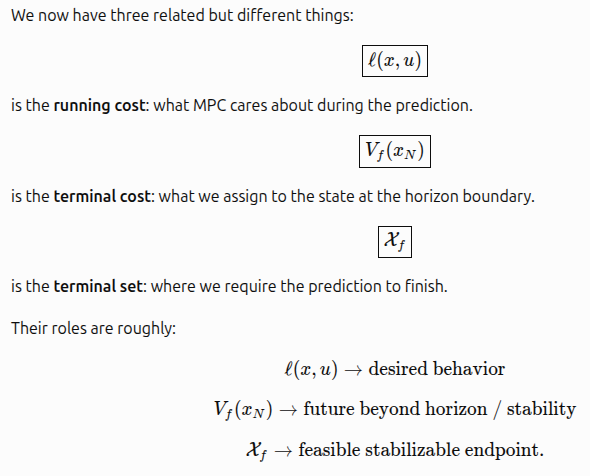

## 17. Explicit MPC

In standard MPC, at every control timestep we solve an optimization problem:

$$
x_t
\rightarrow
\text{optimization solver}
\rightarrow
U_t^*
\rightarrow
u_t=u_{0|t}^*.
$$

This provides flexibility, but solving an optimization problem online requires computation.

For some constrained linear MPC problems, the optimization can instead be solved offline as a function of the current state.

The resulting controller has a piecewise-affine form:

$$
\boxed{
u(x)=
K_i x + c_i,
\qquad
x\in\mathcal R_i
}
$$

where:

$$
\mathcal R_1,\mathcal R_2,\ldots
$$

are different regions of the state space.

Online control then becomes:

$$
\boxed{
\text{measure state}
\rightarrow
\text{identify region}
\rightarrow
\text{evaluate stored control law}.
}
$$

This is called explicit MPC.

## 18. Why Constraints Create Regions

Without constraints, a linear-quadratic controller may have the form:

$$
u=-Kx.
$$

With the input constraint:

$$
u_{\min}\leq u\leq u_{\max},
$$

the unconstrained solution may become infeasible.

The optimal controller can therefore become piecewise:

$$
u(x)=
\begin{cases}
u_{\max},
&
x\in\mathcal R_1
\\
-Kx,
&
x\in\mathcal R_2
\\
u_{\min},
&
x\in\mathcal R_3.
\end{cases}
$$

Each region corresponds to a particular set of active constraints.

This is the central idea behind explicit MPC.

In [92]:
import numpy as np
import matplotlib.pyplot as plt

# Simple feedback gain
K = 0.8

# Control limits
u_min = -1.0
u_max = 1.0

# State space
x_values = np.linspace(-3.0, 3.0, 400)

# Unconstrained feedback
u_unconstrained = -K * x_values

# Constrained / piecewise feedback
u_explicit = np.clip(
    u_unconstrained,
    u_min,
    u_max
)

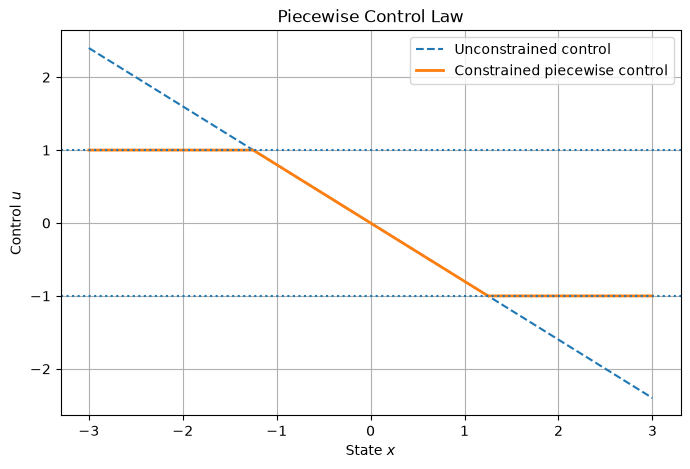

In [93]:
plt.figure(figsize=(8, 5))

plt.plot(
    x_values,
    u_unconstrained,
    linestyle="--",
    label="Unconstrained control"
)

plt.plot(
    x_values,
    u_explicit,
    linewidth=2,
    label="Constrained piecewise control"
)

plt.axhline(u_max, linestyle=":")
plt.axhline(u_min, linestyle=":")

plt.xlabel("State $x$")
plt.ylabel("Control $u$")
plt.title("Piecewise Control Law")
plt.grid(True)
plt.legend()
plt.show()

### Explicit-Control Interpretation

For this simple example:

$$
u(x)=
\begin{cases}
1,
&
x<-1.25
\\
-0.8x,
&
-1.25\leq x\leq1.25
\\
-1,
&
x>1.25.
\end{cases}
$$

The online controller no longer needs to solve an optimization problem.

It only needs to:

1. measure $x$,
2. determine which region contains $x$,
3. evaluate the corresponding control law.

Thus:

$$
\boxed{
\text{online optimization}
\rightarrow
\text{offline regions + online lookup}.
}
$$

## 19. Standard MPC vs Explicit MPC

### Standard MPC

At every timestep:

$$
\boxed{
x_t
\rightarrow
\text{solve optimization}
\rightarrow
u_t
}
$$

Advantages:

- flexible,
- handles changing problems naturally,
- suitable for nonlinear MPC formulations.

Main cost:

- online optimization.

### Explicit MPC

The optimization is solved parametrically offline:

$$
\boxed{
x
\rightarrow
\mathcal R_i
\rightarrow
K_i x+c_i
\rightarrow
u
}
$$

Advantages:

- very fast online evaluation,
- predictable online computation.

Main limitation:

- the number of regions can grow rapidly with state dimension, constraints, and horizon length.

## 20. Practical MPC Considerations

The behavior and computational cost of MPC depend strongly on several design choices.

### Prediction Horizon

If the sampling time is $\Delta t$ and the prediction horizon contains $N$ steps, the controller predicts approximately:

$$
T_{\text{prediction}}=N\Delta t.
$$

A short horizon reduces computation but may prevent the controller from anticipating future constraints.

A longer horizon provides greater foresight but increases the size of the optimization problem.

In our obstacle-avoidance experiment:

$$
N=20,\qquad \Delta t=0.1
$$

gave:

$$
T_{\text{prediction}}=2.0\text{ s},
$$

and the optimization failed during the rollout.

Increasing the horizon to:

$$
N=35
$$

gave:

$$
T_{\text{prediction}}=3.5\text{ s},
$$

allowing the controller to anticipate the obstacle earlier and successfully generate an avoidance trajectory.

Thus:

$$
\boxed{
\text{prediction horizon}
\leftrightarrow
\text{anticipation vs computation}
}
$$

### Sampling Time

The sampling time $\Delta t$ determines how frequently MPC replans.

A smaller $\Delta t$ means:

- more frequent feedback,
- finer trajectory prediction,
- faster reaction to disturbances,

but also:

- more optimization problems per second.

A larger $\Delta t$ reduces the optimization frequency but gives a coarser approximation of the system evolution.

Therefore:

$$
\boxed{
\Delta t
\leftrightarrow
\text{feedback frequency vs computation}
}
$$

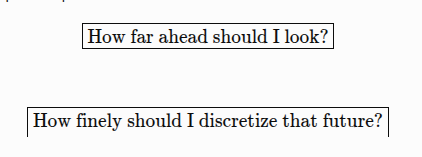

### Warm Starting

At consecutive MPC steps, the optimization problems are usually similar.

If the previous optimal sequence was:

$$
U_t^*=
\{
u_{0|t}^*,
u_{1|t}^*,
\ldots,
u_{N-1|t}^*
\},
$$

a useful initial guess for the next optimization is:

$$
\{
u_{1|t}^*,
u_{2|t}^*,
\ldots,
u_{N-1|t}^*,
u_{N-1|t}^*
\}.
$$

This is called warm starting.

Warm starting can reduce the amount of work required by the numerical optimizer because the previous solution is often already close to the new solution.

## 21. What Does MPC Solver Failure Mean?

An MPC solver can fail for different reasons.

### Physical or Constraint Infeasibility

There may be no trajectory satisfying all constraints.

For example, the vehicle may be:

- too close to an obstacle,
- moving too quickly,
- unable to steer sufficiently,
- unable to brake sufficiently.

### Insufficient Prediction Horizon

A feasible long-term maneuver may exist, but the chosen horizon may not provide enough foresight for the optimizer to discover and execute it effectively.

### Numerical Optimization Failure

For nonlinear MPC, the optimization problem may be nonconvex.

The numerical solver can therefore:

- converge to a poor local solution,
- struggle with an infeasible initialization,
- fail to satisfy nonlinear constraints,
- exceed its iteration or computation limit.

Therefore:

$$
\boxed{
\text{solver failure}
\neq
\text{necessarily physical impossibility}.
}
$$

The cause of failure should be diagnosed from the constraints, solver status, initialization, and system state.

# 22. Model Predictive Control — Summary

Model Predictive Control repeatedly solves a finite-horizon optimal-control problem using the latest measured state.

The basic loop is:

$$
\boxed{
\text{measure}
\rightarrow
\text{predict}
\rightarrow
\text{optimize}
\rightarrow
\text{apply first control}
\rightarrow
\text{repeat}.
}
$$

---

## Finite-Horizon Optimization

At time $t$:

$$
x_{0|t}=x_t.
$$

MPC predicts:

$$
x_{k+1|t}=
f(x_{k|t},u_{k|t})
$$

and minimizes:

$$
J_t=
\sum_{k=0}^{N-1}
\ell(x_{k|t},u_{k|t})
+
V_f(x_{N|t}).
$$

Only:

$$
u_t=u_{0|t}^*
$$

is executed.

---

## Constraints

MPC can explicitly include:

$$
x_{k|t}\in\mathcal X
$$

and:

$$
u_{k|t}\in\mathcal U.
$$

This allows physical and safety requirements such as:

- acceleration limits,
- steering limits,
- velocity limits,
- obstacle avoidance.

For our circular obstacle:

$$
\|p_{k|t}-p_{\text{obs}}\|
\geq
r_{\text{safe}}.
$$

---

## Persistent Feasibility

Feasibility at the current MPC step does not automatically guarantee future feasibility.

A control-invariant terminal set:

$$
x_{N|t}\in\mathcal X_f
$$

can provide a feasible continuation beyond the finite prediction horizon.

The central idea is:

$$
\boxed{
\text{feasible current sequence}
\rightarrow
\text{shift sequence}
\rightarrow
\text{append feasible terminal control}.
}
$$

---

## Stability

Persistent feasibility does not automatically imply convergence to the desired equilibrium.

A terminal controller and terminal cost can be designed such that:

$$
V_f(f(x,\kappa_f(x)))-V_f(x)
\leq
-\ell(x,\kappa_f(x)).
$$

This allows the optimal MPC cost to behave like a Lyapunov function.

A common local terminal construction uses LQR:

$$
u=-Kx
$$

with:

$$
V_f(x)=x^TPx.
$$

---

## Explicit MPC

Instead of solving the optimization online at every timestep, some constrained linear MPC problems can be solved parametrically offline.

The resulting controller is piecewise affine:

$$
u(x)=K_i x+c_i,
\qquad
x\in\mathcal R_i.
$$

Thus:

$$
\boxed{
\text{online optimization}
\rightarrow
\text{offline regions + online evaluation}.
}
$$

---

## Practical Lessons

The prediction horizon determines how far MPC can anticipate future events:

$$
T_{\text{prediction}}=N\Delta t.
$$

Longer horizons provide more foresight but require more computation.

Warm starting reuses information from the previous optimization.

Solver failure may result from physical infeasibility, insufficient horizon length, poor initialization, or numerical difficulties.

---

## Central Insight

MPC combines:

$$
\boxed{
\text{model}
+
\text{prediction}
+
\text{optimization}
+
\text{constraints}
+
\text{feedback}.
}
$$

Unlike open-loop trajectory optimization, MPC continuously replans using the latest measured state.

This makes finite-horizon optimization usable as a closed-loop controller.